# Same-reliability, agreement-matched clean/corrupt patching

This implements the clarified follow-up to notebooks 18–19. Exact questions and
observed answers **may differ**. Reliability (<0.5), candidate ordering/identities,
problem size and reasoning off remain fixed. We compare two nested matching rules:

1. **Equal totals:** X and Y each have the same total agreement in donor and recipient.
2. **Exact grid:** X and Y each have identical per-question agreement bit vectors.

Both preserve the pairwise Bayesian log odds and correct candidate, despite differing
surface questions/answers. Clean/corrupt is defined by the original emitted answer.
We also report a stricter subset whose emitted label agrees with a non-tied saved
answer-boundary margin. Ties in the Bayesian target are excluded.

This notebook runs on CPU and reads outputs from a separate memory-capped native GPU
replay. It never executes in, pauses, or unloads the original training kernel.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']=''
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
REPO_ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'pyproject.toml').exists())
sys.path.insert(0,str(REPO_ROOT/'notebooks'))
from agreement_matched_patching import OUT, SITES, load_rows, prepare, summarize_phase
protocol=prepare()
rows=load_rows()
by_id={r['row_id']:r for r in rows}
display({k:len(protocol[k]) for k in ['discovery_pairs','grid_followup_pairs','heldout_totals_pairs']})
display({'protocol_sha256':protocol['protocol_sha256'],'reasoning':False,'notebook_device':'cpu'})


{'discovery_pairs': 10,
 'grid_followup_pairs': 117,
 'heldout_totals_pairs': 160}

{'protocol_sha256': 'dc9ecfd9b4a63b549e0939a8e45a9d945c29aaf8c91475fcedb7aaae6bba7f12',
 'reasoning': False,
 'notebook_device': 'cpu'}

## Pair availability and split separation

The previous notebook's zero exact-question pairs are not a blocker for this revised
design. Equal totals yield held-out pairs; exact grids do not. Grid results therefore
remain training-split exploration and are never presented as held-out confirmation.
Pair counts are dependent combinations, not independent observations. Strict held-out
pairs only have C2 as the correct candidate; this limits generalization.

In [2]:
display(pd.read_csv(OUT/'matching_counts.csv'))
for name in ['discovery_pairs','grid_followup_pairs','heldout_totals_pairs']:
    display(Markdown('### '+name))
    frame=pd.DataFrame(protocol[name])
    display(frame.groupby(['reliability','winner']).agg(pairs=('pair_id','size'),strict=('strict_boundary_pair','sum')))


,tier,split,labels,pairs,mixed_groups,unique_clean,unique_corrupt,schedules,winners
0,totals,train,emitted,7626,41,477,679,48,"['C1', 'C2']"
1,totals,train,emitted_and_strict_boundary,6302,40,462,609,48,"['C1', 'C2']"
2,totals,test,emitted,160,26,63,57,7,"['C1', 'C2']"
3,totals,test,emitted_and_strict_boundary,119,21,53,36,7,['C2']
4,totals,all,emitted,10100,41,543,786,55,"['C1', 'C2']"
5,totals,all,emitted_and_strict_boundary,8246,40,523,706,55,"['C1', 'C2']"
6,grid,train,emitted,1248,126,452,413,48,"['C1', 'C2']"
7,grid,train,emitted_and_strict_boundary,1037,124,433,354,48,"['C1', 'C2']"
8,grid,test,emitted,0,0,0,0,0,[]
9,grid,test,emitted_and_strict_boundary,0,0,0,0,0,[]


### discovery_pairs

pairs  strict
reliability winner               
1/20        C1          1       1
            C2          1       1
1/4         C1          1       1
            C2          1       1
3/20        C1          1       1
            C2          1       1
7/20        C1          1       1
            C2          1       1
9/20        C1          1       1
            C2          1       1

### grid_followup_pairs

pairs  strict
reliability winner               
1/20        C1          3       3
            C2         21      21
1/4         C1          3       3
            C2         20      20
3/20        C1          3       3
            C2         20      20
7/20        C1          4       4
            C2         20      20
9/20        C1          3       3
            C2         20      20

### heldout_totals_pairs

pairs  strict
reliability winner               
1/20        C1          8       0
            C2         28      26
1/4         C2         26      26
3/20        C1         14       0
            C2         28      21
7/20        C2         28      22
9/20        C2         28      24

## Inspect the actual agreement grids

Examples are fixed by the frozen pair order, not by patch outcomes. The totals-only
examples can move evidence across question positions; the exact-grid examples cannot.
Different reports are permitted, so matching agreement does not imply matching raw
membership bits or question wording.

In [3]:
for cohort in ['discovery_pairs','heldout_totals_pairs']:
    for pair in protocol[cohort][:2]:
        records=[]
        for role,row_id in [('clean',pair['clean_id']),('corrupt',pair['corrupt_id'])]:
            row=by_id[row_id]
            for q,(membership,report,gx,gy) in enumerate(zip(row['membership_sets'],row['observed_reports'],row['agreement_candidate_1_by_question'],row['agreement_candidate_2_by_question'])):
                records.append({'role':role,'question':q+1,'membership_set':membership,'report':report,'X_agrees':gx,'Y_agrees':gy})
        display(Markdown(f"**{cohort}, r={pair['reliability']}, winner={pair['winner']}, same grid={pair['same_grid']}**"))
        display(pd.DataFrame(records))


**discovery_pairs, r=1/20, winner=C1, same grid=True**

,role,question,membership_set,report,X_agrees,Y_agrees
0,clean,1,"[1, 2, 5, 6]",NO,0,1
1,clean,2,"[3, 7, 8, 9]",NO,1,0
2,clean,3,"[1, 2, 5, 8]",NO,0,1
3,corrupt,1,"[3, 4, 6, 7]",YES,0,1
4,corrupt,2,"[3, 5, 7, 9]",NO,1,0
5,corrupt,3,"[1, 4, 6, 7]",YES,0,1


**discovery_pairs, r=1/20, winner=C2, same grid=True**

,role,question,membership_set,report,X_agrees,Y_agrees
0,clean,1,"[1, 4, 7, 9]",NO,1,0
1,clean,2,"[1, 7, 8, 9]",YES,0,1
2,clean,3,"[1, 2, 5, 6]",YES,1,0
3,corrupt,1,"[4, 7, 8, 9]",NO,1,0
4,corrupt,2,"[1, 5, 7, 8]",YES,0,1
5,corrupt,3,"[1, 2, 4, 6]",YES,1,0


**heldout_totals_pairs, r=7/20, winner=C2, same grid=False**

,role,question,membership_set,report,X_agrees,Y_agrees
0,clean,1,"[3, 5, 8, 9]",NO,1,1
1,clean,2,"[2, 5, 7, 8]",NO,0,0
2,clean,3,"[2, 4, 5, 8]",YES,1,0
3,corrupt,1,"[1, 2, 3, 5]",YES,1,0
4,corrupt,2,"[1, 2, 7, 9]",YES,1,1
5,corrupt,3,"[3, 4, 6, 9]",YES,0,0


**heldout_totals_pairs, r=1/4, winner=C2, same grid=False**

,role,question,membership_set,report,X_agrees,Y_agrees
0,clean,1,"[1, 2, 3, 5]",YES,1,0
1,clean,2,"[1, 2, 7, 9]",YES,1,1
2,clean,3,"[3, 4, 6, 9]",YES,0,0
3,corrupt,1,"[4, 7, 8, 9]",YES,0,1
4,corrupt,2,"[1, 7, 8, 9]",NO,1,0
5,corrupt,3,"[4, 7, 8, 9]",NO,1,0


## Frozen training discovery: both directions across all 32 layers

Ten strict exact-grid training pairs (one per reliability × winner) are scanned at
`final_prompt` and `answer_prefix`, before the answer numeral. Denoising patches a
clean residual into a corrupt recipient; noising reverses that pair. Every site/layer
has a saved-state self-patch control, with fresh native unpatched baselines.

For each site, select the layer in 0–30 with the largest average bidirectional
truth-signed margin effect; ties choose the earlier layer. Selection is written before
held-out patching. Layer 31 remains a diagnostic: `final_prompt` there has no remaining
cross-token influence, while `answer_prefix` there can directly transfer the donor's
readout. Even near-final answer-prefix repairs may be decision copying, not restored
Bayesian computation. This is a whole-residual experiment, not a signed-subspace test.

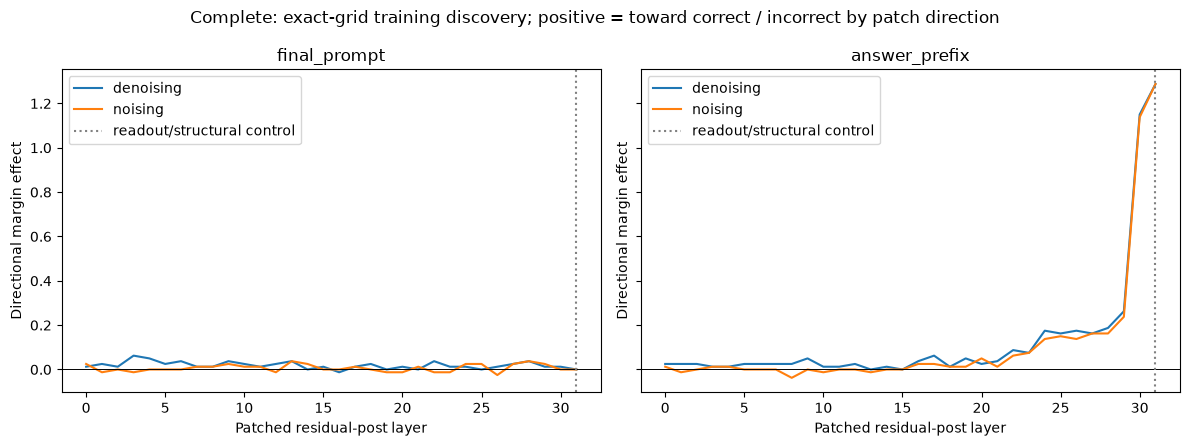

{'complete': True,
 'jobs_done': 2560,
 'jobs_expected': 2560,
 'records': 2560,
 'peak_allocated_mib': 4024.65234375,
 'peak_reserved_mib': 4354.0,
 'after': {'total_mib': 32607,
  'free_mib': 9845,
  'utilization_percent': 0,
  'owners': {'273484': 642, '326499': 18568, '428350': 3036}},
 'existing_processes_modified': False,
 'seconds_this_run': 2906.024371324107}

,cohort,site,layer,direction,condition,label_scope,pairs,unique_recipients,recipient_schedules,baseline_accuracy,...,repair_rate_among_baseline_incorrect,damage_rate_among_baseline_correct,choice_changes,mean_truth_signed_change,mean_directional_effect,recipient_weighted_truth_signed_change,recipient_weighted_patched_accuracy,baseline_full_vocab_next_token_accuracy,patched_full_vocab_next_token_accuracy,run_complete
256,discovery_grid_train,answer_prefix,0,denoising,cross_patch,strict_boundary_pairs,10,10,8,0.0,...,0.0,NaN,1,0.0250,0.0250,0.0250,0.0,0.0,0.1,True
258,discovery_grid_train,answer_prefix,0,noising,cross_patch,strict_boundary_pairs,10,10,7,1.0,...,NaN,0.0,0,-0.0125,0.0125,-0.0125,1.0,1.0,1.0,True
260,discovery_grid_train,answer_prefix,1,denoising,cross_patch,strict_boundary_pairs,10,10,8,0.0,...,0.0,NaN,0,0.0250,0.0250,0.0250,0.0,0.0,0.0,True
262,discovery_grid_train,answer_prefix,1,noising,cross_patch,strict_boundary_pairs,10,10,7,1.0,...,NaN,0.0,0,0.0125,-0.0125,0.0125,1.0,1.0,1.0,True
264,discovery_grid_train,answer_prefix,2,denoising,cross_patch,strict_boundary_pairs,10,10,8,0.0,...,0.0,NaN,0,0.0250,0.0250,0.0250,0.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,discovery_grid_train,final_prompt,29,noising,cross_patch,strict_boundary_pairs,10,10,7,1.0,...,NaN,0.0,0,-0.0250,0.0250,-0.0250,1.0,1.0,1.0,True
504,discovery_grid_train,final_prompt,30,denoising,cross_patch,strict_boundary_pairs,10,10,8,0.0,...,0.0,NaN,0,0.0125,0.0125,0.0125,0.0,0.0,0.0,True
506,discovery_grid_train,final_prompt,30,noising,cross_patch,strict_boundary_pairs,10,10,7,1.0,...,NaN,0.0,0,0.0000,0.0000,0.0000,1.0,1.0,1.0,True
508,discovery_grid_train,final_prompt,31,denoising,cross_patch,strict_boundary_pairs,10,10,8,0.0,...,0.0,NaN,0,0.0000,0.0000,0.0000,0.0,0.0,0.0,True


{'protocol_sha256': 'dc9ecfd9b4a63b549e0939a8e45a9d945c29aaf8c91475fcedb7aaae6bba7f12',
 'locations': [{'site': 'final_prompt',
   'layer': 13,
   'discovery_score': 0.0375},
  {'site': 'answer_prefix', 'layer': 30, 'discovery_score': 1.14375}],
 'discovery_results_sha256': '9c38661e6427a01baa6e4678dc3e6e137aad0f3ab21ff163c8d4ff763b4aac70',
 'selection': 'For each site choose layer 0..30 maximizing mean bidirectional truth-signed margin effect on discovery pairs; lower layer breaks ties. Layer 31 is excluded as a final readout/structural control.',
 'test_patch_results_used': False}

In [4]:
discovery_status,discovery_rows,discovery_summary=summarize_phase('discovery')
display(discovery_status)
if not discovery_summary.empty:
    display(discovery_summary[(discovery_summary.condition=='cross_patch') & (discovery_summary.label_scope=='strict_boundary_pairs')])
lock_path=OUT/'locked_locations.json'
display(json.loads(lock_path.read_text()) if lock_path.exists() else {'locations_locked':False})


## Frozen-location evaluation and controls

Evaluation uses all 160 emitted-label held-out totals pairs (119 strict pairs), plus
117 strict-grid training pairs with discovery rows excluded, one per matching group.
The grid follow-up is not an independent test split. All matching groups/pairs and the
layer-selection rule are frozen before patched outcomes are inspected.

Controls at each selected location include self-patching, another matched donor with
the recipient's own behavior label, a label-agnostic matched-group mean from training,
and a donor patch at the off-target domain boundary. If no other strict same-label
donor exists, its fallback is explicitly labeled self; it is not counted as a genuine
resampled control. Cross-pair rows in the grid follow-up exclude discovery rows;
its control pools still use the full training split. Mean controls can include training
recipients, but never test rows.
All selected rows have the same input prefix through the domain boundary. That
off-target control is therefore an expected null, not a deliberately different
off-target perturbation.

Metrics include raw/truth-signed margin changes, repair and damage counts, conditional
candidate accuracy, and full-vocabulary next-token correctness at the saved answer
prefix. Complete patched responses are not regenerated. Pair-weighted and
recipient-weighted effects are reported separately; reused recipients/donors and seven
held-out schedules preclude treating hundreds of patches as independent observations.
The sensitivity columns `buffered_repair_count` and `buffered_damage_count` require
the truth-signed margin to cross from ≤−0.25 to ≥0.25, or the reverse. This separates
larger changes from near-tie flips and does not affect location selection. Paired
control contrasts compare the same donor/recipient edge, site and layer.
The choice-change plot uses the full-vocabulary greedy next token, not just the
sign of the two-candidate margin. These can differ at ties or when another token
outranks both candidates. Both sets of counts remain in the table.

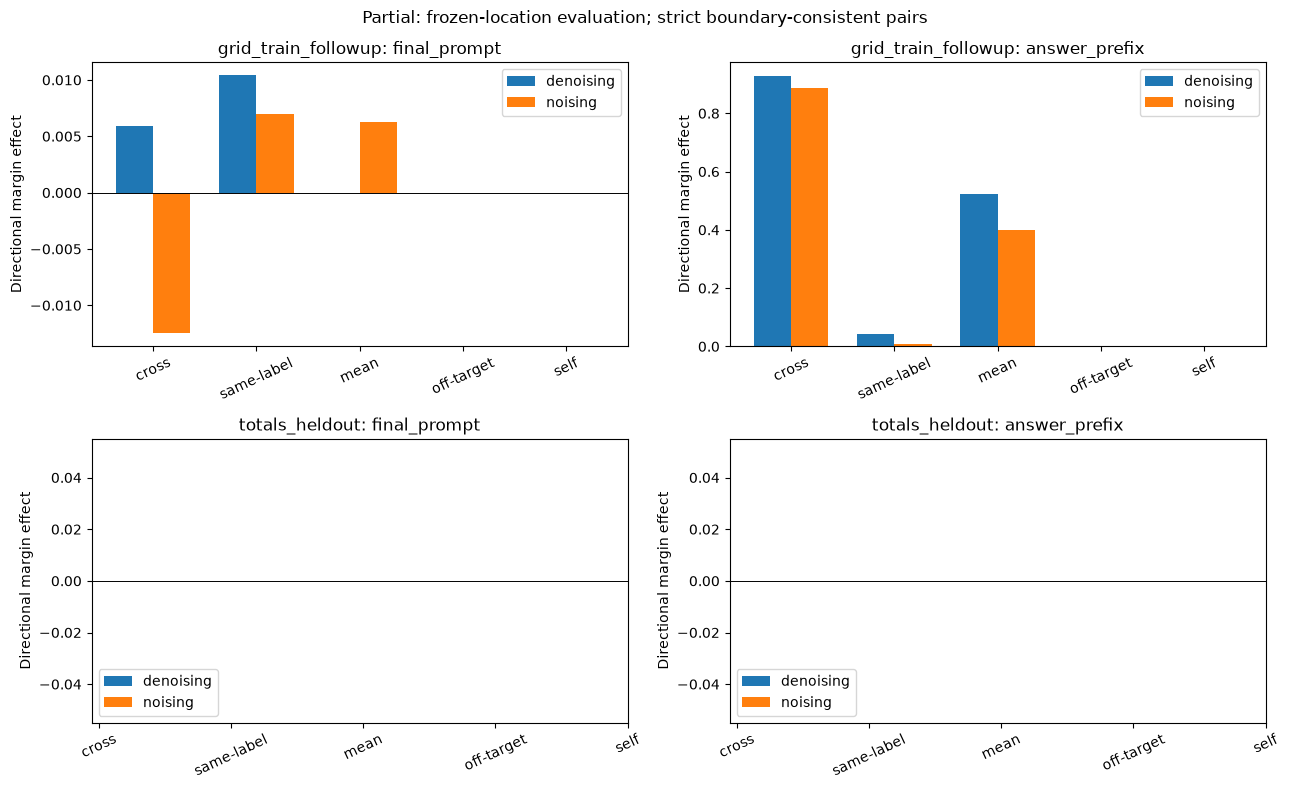

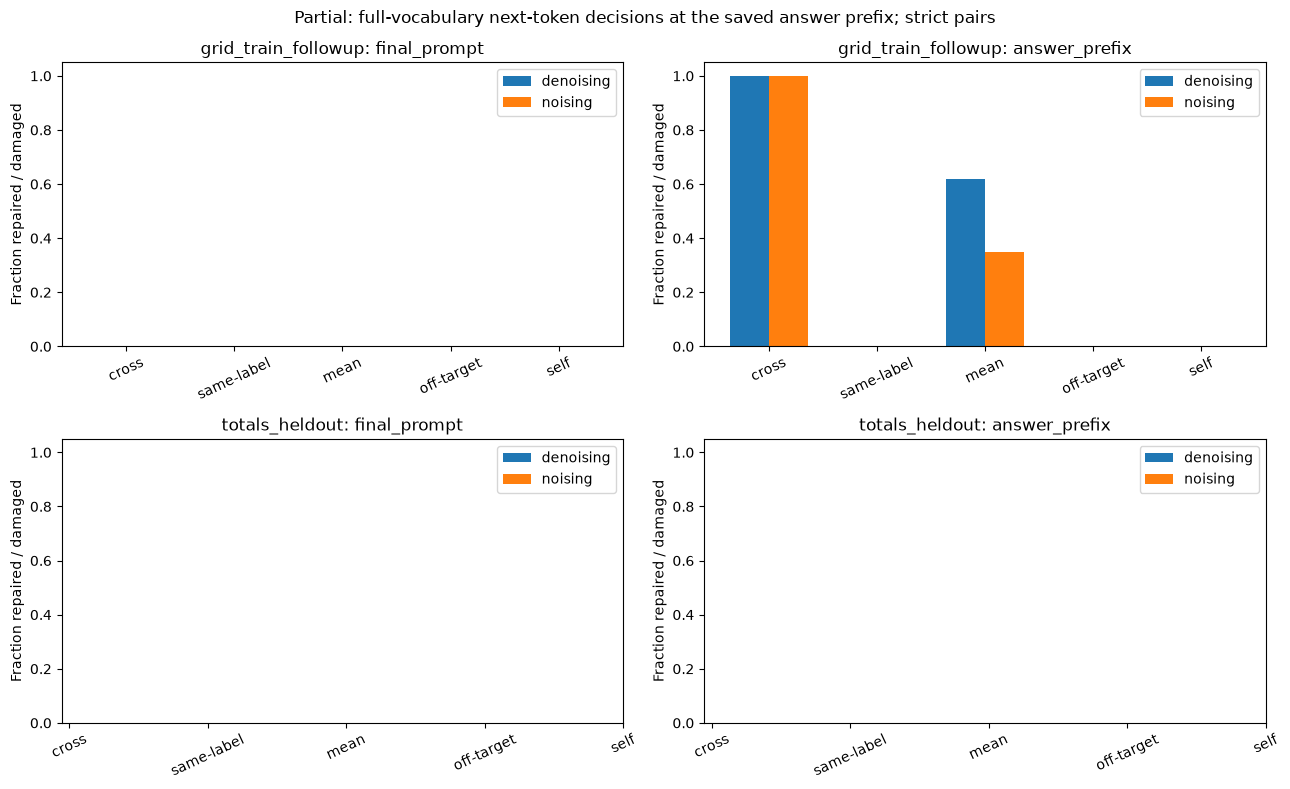

{'complete': False,
 'jobs_done': 410,
 'jobs_expected': 4340,
 'recipients_done_this_run': 41,
 'recipients_this_run': 354,
 'seconds_this_run': 955.503330851905,
 'cohort_progress': {'grid_train_followup': {'jobs_done': 410,
   'jobs_expected': 2340,
   'pairs_complete': 20,
   'pairs_expected': 117},
  'totals_heldout': {'jobs_done': 0,
   'jobs_expected': 2000,
   'pairs_complete': 0,
   'pairs_expected': 160}}}

,cohort,site,layer,direction,condition,label_scope,pairs,unique_recipients,recipient_schedules,baseline_accuracy,...,repair_rate_among_baseline_incorrect,damage_rate_among_baseline_correct,choice_changes,mean_truth_signed_change,mean_directional_effect,recipient_weighted_truth_signed_change,recipient_weighted_patched_accuracy,baseline_full_vocab_next_token_accuracy,patched_full_vocab_next_token_accuracy,run_complete
0,grid_train_followup,answer_prefix,30,denoising,cross_patch,all_emitted_pairs,21,21,12,0.0,...,1.0,NaN,21,0.928571,0.928571,0.928571,1.0,0.0,1.0,False
6,grid_train_followup,answer_prefix,30,noising,cross_patch,all_emitted_pairs,20,20,14,1.0,...,NaN,1.0,20,-0.887500,0.887500,-0.887500,0.0,1.0,0.0,False
12,grid_train_followup,final_prompt,13,denoising,cross_patch,all_emitted_pairs,21,21,12,0.0,...,0.0,NaN,1,0.005952,0.005952,0.005952,0.0,0.0,0.0,False
18,grid_train_followup,final_prompt,13,noising,cross_patch,all_emitted_pairs,20,20,14,1.0,...,NaN,0.0,0,0.012500,-0.012500,0.012500,1.0,1.0,1.0,False
24,grid_train_followup,answer_prefix,30,denoising,cross_patch,strict_boundary_pairs,21,21,12,0.0,...,1.0,NaN,21,0.928571,0.928571,0.928571,1.0,0.0,1.0,False
30,grid_train_followup,answer_prefix,30,noising,cross_patch,strict_boundary_pairs,20,20,14,1.0,...,NaN,1.0,20,-0.887500,0.887500,-0.887500,0.0,1.0,0.0,False
36,grid_train_followup,final_prompt,13,denoising,cross_patch,strict_boundary_pairs,21,21,12,0.0,...,0.0,NaN,1,0.005952,0.005952,0.005952,0.0,0.0,0.0,False
42,grid_train_followup,final_prompt,13,noising,cross_patch,strict_boundary_pairs,20,20,14,1.0,...,NaN,0.0,0,0.012500,-0.012500,0.012500,1.0,1.0,1.0,False


,cohort,site,layer,direction,condition,label_scope,pairs,unique_recipients,recipient_schedules,baseline_accuracy,...,repair_rate_among_baseline_incorrect,damage_rate_among_baseline_correct,choice_changes,mean_truth_signed_change,mean_directional_effect,recipient_weighted_truth_signed_change,recipient_weighted_patched_accuracy,baseline_full_vocab_next_token_accuracy,patched_full_vocab_next_token_accuracy,run_complete
25,grid_train_followup,answer_prefix,30,denoising,off_target,strict_boundary_pairs,21,21,12,0.0,...,0.000000,NaN,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,False
26,grid_train_followup,answer_prefix,30,denoising,resampled_self_fallback,strict_boundary_pairs,9,9,7,0.0,...,0.000000,NaN,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,False
27,grid_train_followup,answer_prefix,30,denoising,same_label_resampled,strict_boundary_pairs,12,12,9,0.0,...,0.000000,NaN,0,0.041667,0.041667,0.041667,0.000000,0.0,0.000000,False
28,grid_train_followup,answer_prefix,30,denoising,self_patch,strict_boundary_pairs,21,21,12,0.0,...,0.000000,NaN,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,False
29,grid_train_followup,answer_prefix,30,denoising,training_group_mean,strict_boundary_pairs,21,21,12,0.0,...,0.619048,NaN,15,0.523810,0.523810,0.523810,0.619048,0.0,0.619048,False
31,grid_train_followup,answer_prefix,30,noising,off_target,strict_boundary_pairs,20,20,14,1.0,...,NaN,0.00,0,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,False
32,grid_train_followup,answer_prefix,30,noising,resampled_self_fallback,strict_boundary_pairs,2,2,2,1.0,...,NaN,0.00,0,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,False
33,grid_train_followup,answer_prefix,30,noising,same_label_resampled,strict_boundary_pairs,18,18,12,1.0,...,NaN,0.00,0,-0.006944,0.006944,-0.006944,1.000000,1.0,1.000000,False
34,grid_train_followup,answer_prefix,30,noising,self_patch,strict_boundary_pairs,20,20,14,1.0,...,NaN,0.00,0,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,False
35,grid_train_followup,answer_prefix,30,noising,training_group_mean,strict_boundary_pairs,20,20,14,1.0,...,NaN,0.35,7,-0.400000,0.400000,-0.400000,0.650000,1.0,0.650000,False


,cohort,site,layer,direction,control,label_scope,pairs,mean_cross_minus_control,recipient_weighted_cross_minus_control
0,grid_train_followup,answer_prefix,30,denoising,same_label_resampled,all_emitted_pairs,12,0.968750,0.968750
1,grid_train_followup,answer_prefix,30,noising,same_label_resampled,all_emitted_pairs,18,0.847222,0.847222
2,grid_train_followup,final_prompt,13,denoising,same_label_resampled,all_emitted_pairs,12,0.000000,0.000000
3,grid_train_followup,final_prompt,13,noising,same_label_resampled,all_emitted_pairs,18,-0.020833,-0.020833
4,grid_train_followup,answer_prefix,30,denoising,same_label_resampled,strict_boundary_pairs,12,0.968750,0.968750
5,grid_train_followup,answer_prefix,30,noising,same_label_resampled,strict_boundary_pairs,18,0.847222,0.847222
6,grid_train_followup,final_prompt,13,denoising,same_label_resampled,strict_boundary_pairs,12,0.000000,0.000000
7,grid_train_followup,final_prompt,13,noising,same_label_resampled,strict_boundary_pairs,18,-0.020833,-0.020833
8,grid_train_followup,answer_prefix,30,denoising,training_group_mean,all_emitted_pairs,21,0.404762,0.404762
9,grid_train_followup,answer_prefix,30,noising,training_group_mean,all_emitted_pairs,20,0.487500,0.487500


In [2]:
evaluation_status,evaluation_rows,evaluation_summary=summarize_phase('evaluation')
display(evaluation_status)
if not evaluation_summary.empty:
    display(evaluation_summary[(evaluation_summary.condition=='cross_patch')])
    display(evaluation_summary[(evaluation_summary.label_scope=='strict_boundary_pairs') & (evaluation_summary.condition!='cross_patch')])
    display(pd.read_csv(OUT/'evaluation/paired_control_contrasts.csv'))


## Execution audit and interpretation limits

Native GPU replay keeps model weights on CPU between module calls and caps its own
CUDA allocator at 6 GiB. Existing GPU owners are checked before each forward pass.
Every recipient must reproduce its saved margin within the original 0.05 tolerance.
Batching is used only after unpatched and self-patch parity checks; otherwise that
recipient falls back to singleton replay. Controls are compared in the same backend.
The optimized singleton path caches the unchanged full-sequence residuals before the
patch and reruns every subsequent layer. For each recipient it must exactly match
full native unpatched replay at layers 0, 15 and 31, and an actual full-forward cross
patch at each site. The output matrix stays resident within the same 6 GiB cap.

A successful clean-state transfer would establish a causal whole-state influence at
that location under this matching design. It would not, by itself, identify reliability
sign multiplication: donor states can carry a decision, token/surface features, or
other correlated variables. No cross-order, cross-identity or cross-reliability
generalization is tested here. See the findings report for completed numerical results.

In [3]:
for phase in ['discovery','evaluation']:
    root=OUT/phase
    for filename in ['execution_setup.json','status.json']:
        path=root/filename
        if path.exists():
            display({phase+'/'+filename:json.loads(path.read_text())})
    path=root/'baseline_audit.jsonl'
    if path.exists():
        checks=[json.loads(s) for s in path.read_text().splitlines()]
        display({'phase':phase,'recipient_replays':len(checks),
                 'max_singleton_saved_margin_error':max((abs(r['single']['margin']-r['saved_margin']) for r in checks),default=0),
                 'batch_compatible_recipients':sum(r['batch_and_self_compatible'] for r in checks),
                 'exact_cached_suffix_replays':sum(r.get('replay_mode')=='exact_native_cached_suffix' for r in checks)})


{'discovery/execution_setup.json': {'pid': 428350,
  'before': {'total_mib': 32607,
   'free_mib': 12887,
   'utilization_percent': 0,
   'owners': {'273484': 642, '326499': 18568}},
  'allocator_cap_mib': 6144,
  'cpu_weight_offload': True,
  'batch_size_requested': 4,
  'existing_processes_modified': False,
  'cached_suffix': True,
  'design_sha256': 'a7f81f9620ccef885c9b6d9361b00fb45a2d5d36cb7e11c5f2fc29f053fbf269'}}

{'discovery/status.json': {'complete': True,
  'jobs_done': 2560,
  'jobs_expected': 2560,
  'records': 2560,
  'peak_allocated_mib': 4024.65234375,
  'peak_reserved_mib': 4354.0,
  'after': {'total_mib': 32607,
   'free_mib': 9845,
   'utilization_percent': 0,
   'owners': {'273484': 642, '326499': 18568, '428350': 3036}},
  'existing_processes_modified': False,
  'seconds_this_run': 2906.024371324107}}

{'phase': 'discovery',
 'recipient_replays': 21,
 'max_singleton_saved_margin_error': 0.0,
 'batch_compatible_recipients': 0,
 'exact_cached_suffix_replays': 19}

{'evaluation/execution_setup.json': {'pid': 451090,
  'before': {'total_mib': 32607,
   'free_mib': 12887,
   'utilization_percent': 0,
   'owners': {'273484': 642, '326499': 18568}},
  'allocator_cap_mib': 6144,
  'cpu_weight_offload': True,
  'batch_size_requested': 4,
  'existing_processes_modified': False,
  'cached_suffix': True,
  'design_sha256': '5ff600afa0ec836132cf7c047aa7b55c8fe85dd6e4f9cb238bde23fd5cbe8c3c'}}

{'evaluation/status.json': {'complete': False,
  'jobs_done': 410,
  'jobs_expected': 4340,
  'recipients_done_this_run': 41,
  'recipients_this_run': 354,
  'seconds_this_run': 955.503330851905}}

{'phase': 'evaluation',
 'recipient_replays': 42,
 'max_singleton_saved_margin_error': 0.0,
 'batch_compatible_recipients': 0,
 'exact_cached_suffix_replays': 42}